### The goal of the notebook is to see if the scores improved if we used random split from scikit-learn library instead of time split method. The risk of using <code>train_test_split</code> is that future data will be exposed to the training set.

### The model below is an inspiration from Netflix Price Winner Model from the Koren paper. Here is the link to the research paper:

https://datajobs.com/data-science-repo/Recommender-Systems-%5BNetflix%5D.pdf

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import optuna
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/movies.csv
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/ratings.csv
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/README.txt
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/tags.csv
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/links.csv


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Load the DataFrame</span> 
  </h1>
</div>

In [2]:
df = pd.read_csv('/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/ratings.csv')

In [3]:
# First five rows
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
df = df.rename(columns = {'userId': 'user_id', 'movieId': 'movie_id'})

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.describe()

##### Deducting 1 from user_id and movie_id since the numPy arrays starts from 0 and as you see from the minimum values for both the columns are 1.

In [5]:
df['user_id'] = df['user_id'] - 1
df['movie_id'] = df['movie_id'] - 1

In [ ]:
df.describe()

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">MatrixFactorizationSGD with user and item biases</span> 
  </h1>
</div>

Biases captures the baseline effect so the latent factors can focus purely on the interaction. Bias accounts for the user and item effects.

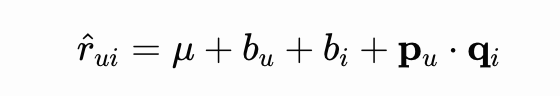

In [6]:
class MatrixFactorizationSGD:
    """
    Matrix Factorization with SGD — built directly on your SGDRegressor style
    Predicts rating = user_factor[u] dot item_factor[i]
    Added two parameters: n_users & n_items to make the model more robust 
    """
    def __init__(self, n_factors=20, learning_rate=0.01, epochs=50, 
                 batch_size=1, reg=None, reg_param=0.01, n_users=None, n_items=None):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.reg = reg
        self.reg_param = reg_param
        self.n_users = n_users         
        self.n_items = n_items
        
        self.P = None  # user latent factors
        self.Q = None  # item latent factors
        self.global_bias = 0.0
        self.user_bias = None
        self.item_bias = None
        
    def fit(self, user_ids, item_ids, ratings):
        """
        user_ids, item_ids, ratings: numpy arrays (or pandas Series) of same length
        """
        user_ids = np.asarray(user_ids, dtype=int)
        item_ids = np.asarray(item_ids, dtype=int)
        ratings = np.asarray(ratings, dtype=float)
        
        n_users = self.n_users if self.n_users is not None else (user_ids.max() + 1)
        n_items = self.n_items if self.n_items is not None else (item_ids.max() + 1)
        
        # Initialize latent factors (small random values)
        self.P = np.random.normal(0, 0.01, (n_users, self.n_factors))
        self.Q = np.random.normal(0, 0.01, (n_items, self.n_factors))
        self.global_bias = np.mean(ratings)

        self.user_bias = np.random.normal(0, 0.001, n_users)  # indicates the observed deviation from users
        self.item_bias = np.random.normal(0, 0.001, n_items) 
        # indicates the observed deviation from items and just to experiment, I added little noise
        
        for epoch in range(self.epochs):
            # Shuffle (stochastic part)
            indices = np.random.permutation(len(ratings))
            for i in range(0, len(ratings), self.batch_size):
                batch_index = indices[i:i + self.batch_size]
                u_batch = user_ids[batch_index]
                i_batch = item_ids[batch_index]
                r_batch = ratings[batch_index]
                
                # Forward pass
                pred = (np.sum(self.P[u_batch] * self.Q[i_batch], axis=1) + self.global_bias 
                        + self.user_bias[u_batch] + self.item_bias[i_batch])
                error = r_batch - pred
                
                # Gradients (same style as your SGDRegressor!)
                grad_P = -2 * (error[:, np.newaxis] * self.Q[i_batch]) # chain rule is applied here
                grad_Q = -2 * (error[:, np.newaxis] * self.P[u_batch])

                grad_u_bias = -2 * error
                grad_i_bias = -2 * error
                
                # Regularization (exactly like your code)
                if self.reg == 'l2':
                    grad_P += 2 * self.reg_param * self.P[u_batch]
                    grad_Q += 2 * self.reg_param * self.Q[i_batch]
                    grad_u_bias += 2 * self.reg_param * self.user_bias[u_batch]
                    grad_i_bias += 2 * self.reg_param * self.item_bias[i_batch]
                    
                elif self.reg == 'l1':
                    grad_P += self.reg_param * np.sign(self.P[u_batch])
                    grad_Q += self.reg_param * np.sign(self.Q[i_batch])
                    grad_u_bias += self.reg_param * np.sign(self.user_bias[u_batch])
                    grad_i_bias += self.reg_param * np.sign(self.item_bias[i_batch])
                
                # SGD update
                self.P[u_batch] -= self.learning_rate * grad_P
                self.Q[i_batch] -= self.learning_rate * grad_Q
                self.user_bias[u_batch] -= self.learning_rate * grad_u_bias  
                self.item_bias[i_batch] -= self.learning_rate * grad_i_bias
        
        return self
    
    def predict(self, user_ids, item_ids):
        user_ids = np.asarray(user_ids, dtype=int)
        item_ids = np.asarray(item_ids, dtype=int)
        
        return (np.sum(self.P[user_ids] * self.Q[item_ids], axis=1) 
                + self.global_bias 
                + self.user_bias[user_ids] 
                + self.item_bias[item_ids])
    

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Splitting the Data into Train and Test</span> 
  </h1>
</div>

#### Added global number since the model was issuing <code>IndexError</code>: index 609 is out of bounds for axis 0 with size 609. So global number makes sure that the index is not out of bounds.

In [9]:
# Compute the global sizes before splitting
n_users_global = df['user_id'].max() + 1
n_movies_global = df['movie_id'].max() + 1
print(f"Global users: {n_users_global} | Global movies: {n_movies_global}")

Global users: 610 | Global movies: 193609


# Train Test Split

In [7]:
#df = df.sort_values('timestamp') # Sorting the data

train_df, test_df = train_test_split(df, test_size=.3, random_state=32)

# Our model expect arrays 
train_users = train_df['user_id'].values
train_movies = train_df['movie_id'].values
train_ratings = train_df['rating'].values

test_users = test_df['user_id'].values
test_movies = test_df['movie_id'].values
test_ratings = test_df['rating'].values

print(f"Time-based split → Train: {len(train_df)} ratings (older) | Test: {len(test_df)} ratings (newer)")

Time-based split → Train: 70585 ratings (older) | Test: 30251 ratings (newer)


In [10]:
model = MatrixFactorizationSGD(n_factors=10, learning_rate=0.01, epochs=10, 
                               reg='l1', reg_param=0.02, batch_size=32, n_users=n_users_global, n_items=n_movies_global)

model.fit(train_users, train_movies, train_ratings)

In [ ]:
test_pred = model.predict(test_users, test_movies)

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Optuna Study</span> 
  </h1>
</div>

### Conducting optuna study for find the optima hyperparameter configurations for our model:
- setting parameters
- use MatrixFactorizationSGD as the predictive model


In [11]:
def objective(trial):

    reg_choice = trial.suggest_categorical('reg', ['l1', 'l2'])
    reg = reg_choice
    reg_param = trial.suggest_float('reg_param', 1e-5, 10.0, log=True)
        
    params = {
        'n_factors': trial.suggest_int('n_factors', 5, 150, step=5),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 0.1, log=True),
        'epochs': trial.suggest_int('epochs', 5, 200),
        'batch_size': trial.suggest_int('batch_size', 16, 320, step=4),  
        'reg': reg,
        'reg_param': reg_param,
        'n_users':n_users_global, 
        'n_items':n_movies_global,
    }
    
    model = MatrixFactorizationSGD(**params).fit(train_users, train_movies, train_ratings)

    pred = model.predict(test_users, test_movies)
    rmse = np.sqrt(mean_squared_error(test_ratings, pred))
    return rmse

study = optuna.create_study(direction='minimize', study_name='MFSGD-Optimization')
study.optimize(objective, n_trials=10, show_progress_bar=True)

[I 2026-03-16 06:12:25,964] A new study created in memory with name: MFSGD-Optimization


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-16 06:12:35,585] Trial 0 finished with value: 0.9113453588908025 and parameters: {'reg': 'l1', 'reg_param': 6.895303016751824e-05, 'n_factors': 105, 'learning_rate': 0.007161733119981583, 'epochs': 76, 'batch_size': 212}. Best is trial 0 with value: 0.9113453588908025.
[I 2026-03-16 06:12:47,415] Trial 1 finished with value: 1.043855351750885 and parameters: {'reg': 'l1', 'reg_param': 4.564626294811438, 'n_factors': 50, 'learning_rate': 0.00015141713420274998, 'epochs': 165, 'batch_size': 308}. Best is trial 0 with value: 0.9113453588908025.
[I 2026-03-16 06:13:04,387] Trial 2 finished with value: 0.8894111365349836 and parameters: {'reg': 'l2', 'reg_param': 0.002553866579031165, 'n_factors': 115, 'learning_rate': 0.014248547899254994, 'epochs': 138, 'batch_size': 132}. Best is trial 2 with value: 0.8894111365349836.
[I 2026-03-16 06:13:15,776] Trial 3 finished with value: 0.8989853992804819 and parameters: {'reg': 'l2', 'reg_param': 0.0013605804165493873, 'n_factors': 115, 

In [12]:
print("Best Hyperparameters Found:")
print(study.best_params)
print(f"Best RMSE: {study.best_value:.4f}")

Best Hyperparameters Found:
{'reg': 'l2', 'reg_param': 2.7238425582172865e-05, 'n_factors': 55, 'learning_rate': 0.00040906799408635825, 'epochs': 164, 'batch_size': 16}
Best RMSE: 0.8679


In [16]:
best_params = study.best_params.copy()
best_params.update({
    'n_users': n_users_global, 
    'n_items': n_movies_global,
})

best_model = MatrixFactorizationSGD(**best_params).fit(train_users, train_movies, train_ratings)
final_pred = best_model.predict(test_users, test_movies)

In [17]:
rmse = np.sqrt(mean_squared_error(test_ratings, final_pred))
mae = mean_absolute_error(test_ratings, final_pred)
r2score = r2_score(test_ratings, final_pred)
explained_var = explained_variance_score(test_ratings, final_pred)

print(f"Final Validation RMSE: {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2score:.4f}")
print(f'Explained Variance Score: {explained_var:.4f}')

Final Validation RMSE: 0.8684
Mean Absolute Error (MAE): 0.6675
R² Score: 0.3082
Explained Variance Score: 0.3082


### My scores have improved a lot but in Koren paper, they used time-based (temporal) hold-out split, which is older ratings for training and newer training for testing.